### Starting out with the importation of necessary libraries

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
df=pd.read_csv(r"C:\Users\User\Downloads\archive (1)\Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.isna().sum()
#no null values

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

#### Vizualization with seaborn and matplotlib

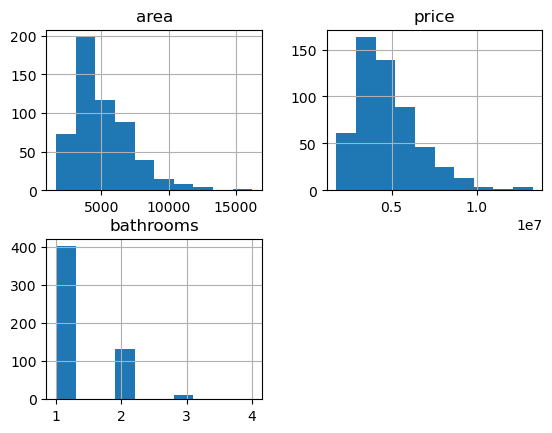

In [5]:
columns = ['area', 'price', 'bathrooms']
df[columns].hist( bins=10)
plt.show()
#Most observations are on the right, with the tail extending to the left.


In [6]:
#check the skewness of the area and price
print(df[['price', 'area']].skew())
#higly positive skewness

price    1.212239
area     1.321188
dtype: float64


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['price'].nunique()

219

In [9]:
df['price_log'] = np.log1p(df['price'])


In [10]:
df['area_log'] = np.log1p(df['area'])

In [11]:
df.head(5)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_log,area_log
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,16.403275,8.912069
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,16.321037,9.100637
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,16.321037,9.206433
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,16.318175,8.922792
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,16.250001,8.912069


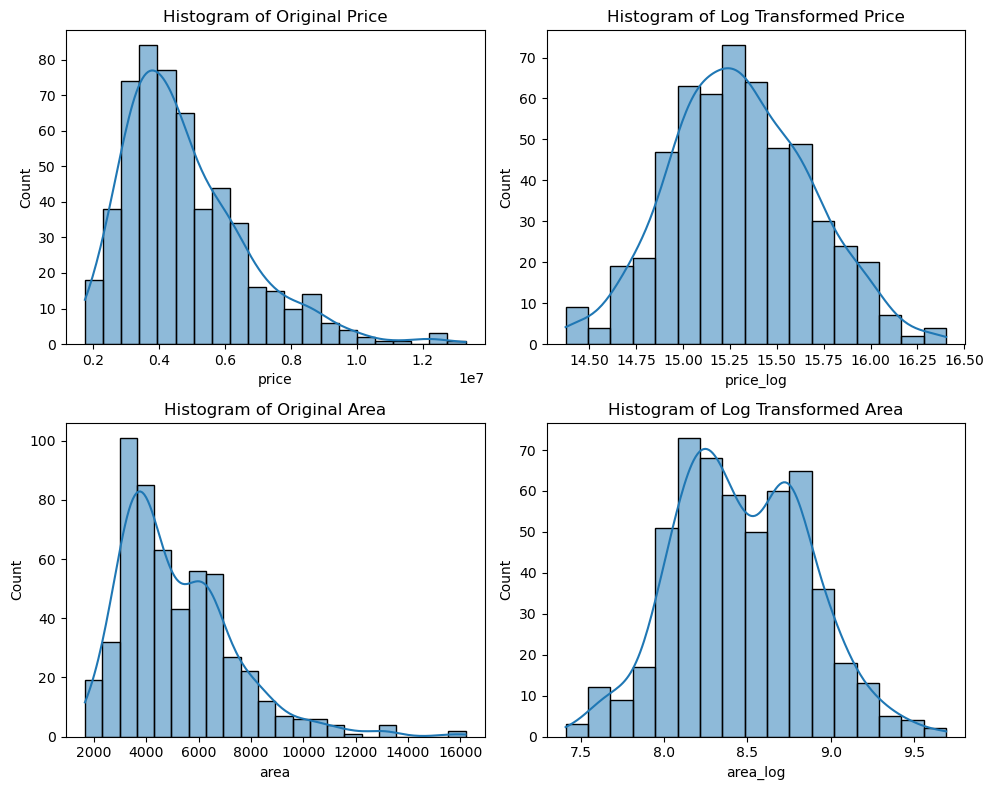

In [12]:
#plotting histogram to compare the distribution of area and price before and after log transformation
fig, axes=plt.subplots(2,2 , figsize=(10,8))
sns.histplot(df['price'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Histogram of Original Price')

sns.histplot(df['price_log'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Histogram of Log Transformed Price')

sns.histplot(df['area'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Histogram of Original Area')

sns.histplot(df['area_log'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Histogram of Log Transformed Area')

plt.tight_layout()
plt.show()

### Feature Engineering

In [13]:
# creating the dataframe column known as price[USD] per area[m2]
df['Price_per_Area'] = df['price']/df['area']
df['Area_per_Bedroom'] = df['area']/df['bedrooms']
df['Price_per_Bathroom'] = df['price']/df['bathrooms']
df['Price_per_Bedroom'] = df['price']/df['bedrooms']
df['Bed_Bath_ratio']= df['bedrooms']/df['bathrooms']

In [64]:
df['Area_per_Bedroom']=df['Area_per_Bedroom']==0

In [14]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_log,area_log,Price_per_Area,Area_per_Bedroom,Price_per_Bathroom,Price_per_Bedroom,Bed_Bath_ratio
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,16.403275,8.912069,1792.452830,1855.0,6650000.0,3.325000e+06,2.0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,16.321037,9.100637,1367.187500,2240.0,3062500.0,3.062500e+06,1.0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,16.321037,9.206433,1229.919679,3320.0,6125000.0,4.083333e+06,1.5
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,16.318175,8.922792,1628.666667,1875.0,6107500.0,3.053750e+06,2.0
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,16.250001,8.912069,1537.735849,1855.0,11410000.0,2.852500e+06,4.0


In [15]:
df['Price_per_Area'].describe()

count     545.000000
mean      993.326978
std       346.537025
min       270.395550
25%       745.370370
50%       952.380952
75%      1184.615385
max      2640.000000
Name: Price_per_Area, dtype: float64

In [16]:
#copy the whole dataframe for encoding of the categorical data
df_copy = df.copy()

### Correlation

In [17]:
#calling the copied dataframe 
df_copy

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_log,area_log,Price_per_Area,Area_per_Bedroom,Price_per_Bathroom,Price_per_Bedroom,Bed_Bath_ratio
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,16.403275,8.912069,1792.452830,1855.000000,6650000.0,3.325000e+06,2.0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,16.321037,9.100637,1367.187500,2240.000000,3062500.0,3.062500e+06,1.0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,16.321037,9.206433,1229.919679,3320.000000,6125000.0,4.083333e+06,1.5
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,16.318175,8.922792,1628.666667,1875.000000,6107500.0,3.053750e+06,2.0
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,16.250001,8.912069,1537.735849,1855.000000,11410000.0,2.852500e+06,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished,14.414348,8.006701,606.666667,1500.000000,1820000.0,9.100000e+05,2.0
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished,14.384879,7.783641,736.312500,800.000000,1767150.0,5.890500e+05,3.0
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished,14.375127,8.194506,483.425414,1810.000000,1750000.0,8.750000e+05,2.0
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished,14.375127,7.976252,601.374570,970.000000,1750000.0,5.833333e+05,3.0


In [18]:
encoded = pd.get_dummies(df_copy[['mainroad','guestroom', 'basement', 'hotwaterheating', 'airconditioning','prefarea', 'furnishingstatus']],drop_first=True)

In [19]:
df_copy.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_log,area_log,Price_per_Area,Area_per_Bedroom,Price_per_Bathroom,Price_per_Bedroom,Bed_Bath_ratio
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,16.403275,8.912069,1792.452830,1855.0,6650000.0,3.325000e+06,2.0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,16.321037,9.100637,1367.187500,2240.0,3062500.0,3.062500e+06,1.0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,16.321037,9.206433,1229.919679,3320.0,6125000.0,4.083333e+06,1.5
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,16.318175,8.922792,1628.666667,1875.0,6107500.0,3.053750e+06,2.0
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,16.250001,8.912069,1537.735849,1855.0,11410000.0,2.852500e+06,4.0


In [20]:
encoded.head()

,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,True,False,False,False,True,True,False,False
1,True,False,False,False,True,False,False,False
2,True,False,True,False,False,True,True,False
3,True,False,True,False,True,True,False,False
4,True,True,True,False,True,False,False,False


In [21]:
df_copy =df_copy.drop(columns=['mainroad','guestroom', 'basement', 'hotwaterheating', 'airconditioning','prefarea', 'furnishingstatus'])

In [22]:
df_copy.head()

,price,area,bedrooms,bathrooms,stories,parking,price_log,area_log,Price_per_Area,Area_per_Bedroom,Price_per_Bathroom,Price_per_Bedroom,Bed_Bath_ratio
0,13300000,7420,4,2,3,2,16.403275,8.912069,1792.452830,1855.0,6650000.0,3.325000e+06,2.0
1,12250000,8960,4,4,4,3,16.321037,9.100637,1367.187500,2240.0,3062500.0,3.062500e+06,1.0
2,12250000,9960,3,2,2,2,16.321037,9.206433,1229.919679,3320.0,6125000.0,4.083333e+06,1.5
3,12215000,7500,4,2,2,3,16.318175,8.922792,1628.666667,1875.0,6107500.0,3.053750e+06,2.0
4,11410000,7420,4,1,2,2,16.250001,8.912069,1537.735849,1855.0,11410000.0,2.852500e+06,4.0


In [23]:
df_copy = pd.concat([df_copy, encoded], axis=1)

In [24]:
df_copy

,price,area,bedrooms,bathrooms,stories,parking,price_log,area_log,Price_per_Area,Area_per_Bedroom,...,Price_per_Bedroom,Bed_Bath_ratio,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,16.403275,8.912069,1792.452830,1855.000000,...,3.325000e+06,2.0,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,16.321037,9.100637,1367.187500,2240.000000,...,3.062500e+06,1.0,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,16.321037,9.206433,1229.919679,3320.000000,...,4.083333e+06,1.5,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,16.318175,8.922792,1628.666667,1875.000000,...,3.053750e+06,2.0,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,16.250001,8.912069,1537.735849,1855.000000,...,2.852500e+06,4.0,True,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,14.414348,8.006701,606.666667,1500.000000,...,9.100000e+05,2.0,True,False,True,False,False,False,False,True
541,1767150,2400,3,1,1,0,14.384879,7.783641,736.312500,800.000000,...,5.890500e+05,3.0,False,False,False,False,False,False,True,False
542,1750000,3620,2,1,1,0,14.375127,8.194506,483.425414,1810.000000,...,8.750000e+05,2.0,True,False,False,False,False,False,False,True
543,1750000,2910,3,1,1,0,14.375127,7.976252,601.374570,970.000000,...,5.833333e+05,3.0,False,False,False,False,False,False,False,False


In [25]:
#correlation of the variables
df_copy.corr()['price'].sort_values(ascending = False)

price                              1.000000
price_log                          0.969010
Price_per_Bedroom                  0.768975
Price_per_Bathroom                 0.570693
area_log                           0.561233
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
Price_per_Area                     0.392921
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
Area_per_Bedroom                   0.244809
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
Bed_Bath_ratio                    -0.180732
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

In [26]:
#dropping the features that include the target in our feature engineered
df_copy = df_copy.drop(['Price_per_Bedroom', 'Price_per_Bathroom', 'Price_per_Area'], axis=1)

In [27]:
df_copy.head()

,price,area,bedrooms,bathrooms,stories,parking,price_log,area_log,Area_per_Bedroom,Bed_Bath_ratio,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,16.403275,8.912069,1855.0,2.0,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,16.321037,9.100637,2240.0,1.0,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,16.321037,9.206433,3320.0,1.5,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,16.318175,8.922792,1875.0,2.0,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,16.250001,8.912069,1855.0,4.0,True,True,True,False,True,False,False,False


In [28]:
corr = df_copy.corr()

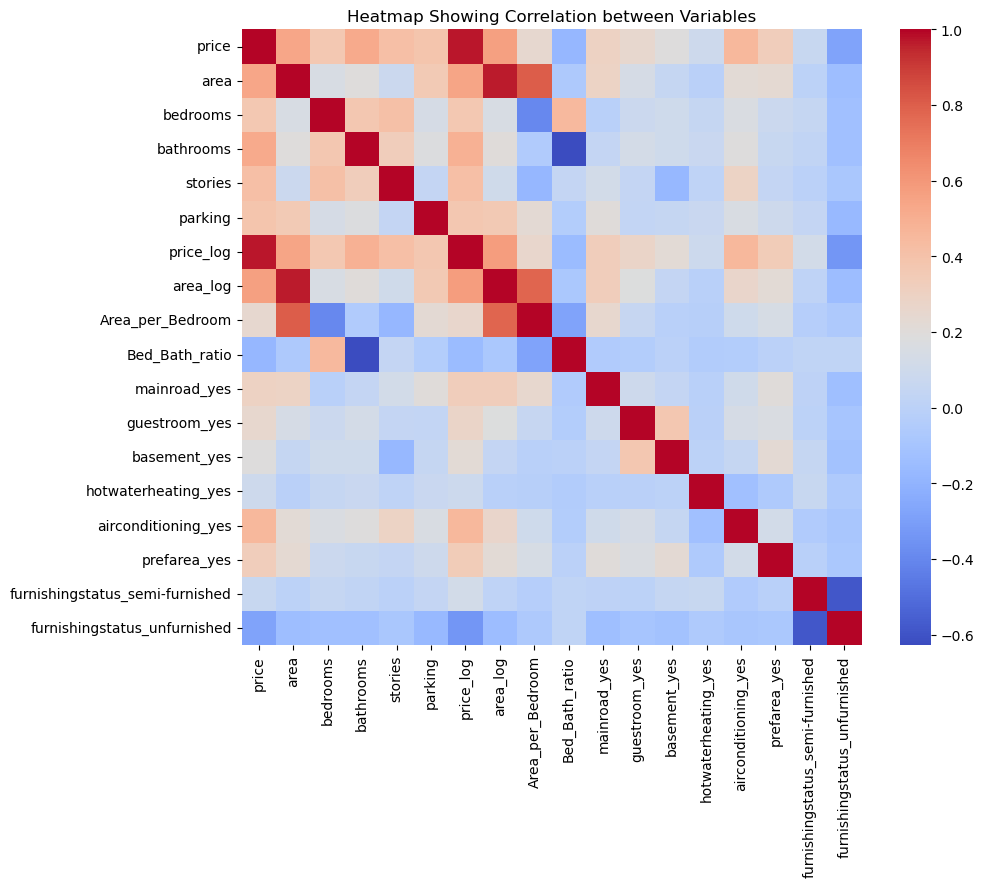

In [29]:
fig, plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Heatmap Showing Correlation between Variables')
plt.show()

## Machine Learning

In [30]:
#split the dataset into target and features
X = df_copy.drop(columns=['price','area', 'price_log'])

y=df_copy['price']

In [31]:
#import library
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

### Linear Regression

In [32]:
 #Building the model
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [33]:
#create the model
lr = LinearRegression()
print(type(lr))


<class 'sklearn.linear_model._base.LinearRegression'>


In [34]:
#apply the RFE to train the model
rfe=RFE(estimator=lr, n_features_to_select=10)
rfe.fit(X_train, y_train)

RFE(estimator=LinearRegression(), n_features_to_select=10)

In [35]:
selected_features = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
})

selected_features.sort_values('Ranking')

,Feature,Selected,Ranking
1,bathrooms,True,1
2,stories,True,1
3,parking,True,1
4,area_log,True,1
7,mainroad_yes,True,1
11,airconditioning_yes,True,1
10,hotwaterheating_yes,True,1
9,basement_yes,True,1
14,furnishingstatus_unfurnished,True,1
12,prefarea_yes,True,1


In [36]:
#Optimizing the model
selected_columns = selected_features[selected_features['Selected']]['Feature']

X = df_copy[selected_columns]

y = df_copy['price']

In [37]:
#checking the feature list 
X.columns.to_list()

['bathrooms',
 'stories',
 'parking',
 'area_log',
 'mainroad_yes',
 'basement_yes',
 'hotwaterheating_yes',
 'airconditioning_yes',
 'prefarea_yes',
 'furnishingstatus_unfurnished']

In [38]:
#train the model
lr=LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred = lr.predict(X_test)

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [41]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

RMSE: 1334083.6521473497
MAE: 977446.2006530897
R² Score: 0.6478871389296458


In [42]:
#adding the area back to the df_copy dataset
df_copy['area'] = df['area']

In [43]:
df_copy.head()

,price,area,bedrooms,bathrooms,stories,parking,price_log,area_log,Area_per_Bedroom,Bed_Bath_ratio,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,16.403275,8.912069,1855.0,2.0,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,16.321037,9.100637,2240.0,1.0,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,16.321037,9.206433,3320.0,1.5,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,16.318175,8.922792,1875.0,2.0,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,16.250001,8.912069,1855.0,4.0,True,True,True,False,True,False,False,False


In [44]:
#split the dataset into target and features
X = df_copy.drop(columns=['price', 'price_log'])

y=df_copy['price']

In [45]:
#import library
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [46]:
 #Building the model
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
#create the model
lr = LinearRegression()
print(type(lr))


<class 'sklearn.linear_model._base.LinearRegression'>


In [47]:
#train the model
lr=LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [48]:
y_pred = lr.predict(X_test)

In [49]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R² Score:", r2)

RMSE: 1328873.0502634533
MAE: 971764.8264371093
R² Score: 0.650632299553402


### RandomForest

In [50]:
from sklearn.ensemble import RandomForestRegressor

In [51]:
rf = RandomForestRegressor(random_state=42)

In [52]:
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [69]:
print("Train R²:", rf.score(X_train, y_train))
print("Test R²:", rf.score(X_test, y_test))

Train R²: 0.9454737717392072
Test R²: 0.6248308517490262


In [53]:
y_pred = rf.predict(X_test)

In [54]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_rmse = mean_squared_error(y_test, y_pred) ** 0.5
rf_mae = mean_absolute_error(y_test, y_pred)
rf_r2 = r2_score(y_test, y_pred)

print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R² Score:", rf_r2)

RMSE: 1377068.9213330958
MAE: 1014393.9177370031
R² Score: 0.6248308517490262


In [56]:
#import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [70]:
#using Kfold with the Cross validation
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    RandomForestRegressor(
        random_state=42,
        n_estimators=200
    ),
    X,
    y,
    cv=kf,
    scoring='r2'
)

print(scores)
print(scores.mean())

[0.62419466 0.69556151 0.54618448 0.64587777 0.60620011]
0.6236037063721769


In [72]:
# Define parameters for model optimization
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
     'min_samples_leaf': [1, 2]}


In [76]:
#Create the GridSearch

grid = GridSearchCV(
       estimator=RandomForestRegressor(random_state=42),
       param_grid = param_grid,
       cv = 5,
       scoring = 'r2',
       n_jobs = -1
)


In [77]:
#train using the gridsearch
grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [78]:
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross Validation Score: 0.5984040010422897


In [81]:
#create the best 
best_rf = grid.best_estimator_

In [82]:
#checking the metrics
best_pred = best_rf.predict(X_test)
best_rmse = mean_squared_error(y_test, best_pred)**0.5
best_mae = mean_absolute_error(y_test, best_pred)
best_r2 = r2_score(y_test, best_pred)

print('Optimized RMSE:', best_rmse)
print('Optimized MAE:', best_mae)
print('Optimized R2', best_r2)

Optimized RMSE: 1416484.9149567885
Optimized MAE: 1042055.9324595818
Optimized R2 0.603046467551785
